# 05 — Evaluasi dan Perbandingan Model

Notebook ini bertugas untuk memuat kedua model yang telah dilatih (MobileNetV2 dan ResNet50), mengevaluasinya secara mendalam menggunakan test set, dan membandingkan performanya berdasarkan berbagai metrik (Accuracy, Precision, Recall, F1-Score, Inference Time, serta Model Size).

In [11]:
# =============================================================================
# 05_model_comparison.py — Evaluasi & Perbandingan Model
# =============================================================================
# Script referensi untuk notebook: 05_model_comparison.ipynb
# Salin kode ini cell-by-cell ke Jupyter Notebook di VS Code
#
# Tujuan:
#   - Memuat kedua model yang sudah ditraining (.pth)
#   - Evaluasi lengkap pada test set: Accuracy, Precision, Recall, F1-Score
#   - Confusion Matrix untuk kedua model
#   - Perbandingan: akurasi, inference time, model size
#   - Menentukan model terbaik untuk production
#
# Input:
#   - trained_models/mobilenetv2_best.pth
#   - trained_models/resnet50_best.pth
#   - trained_models/*_history.json
#
# Output:
#   - reports/confusion_matrix_mobilenetv2.png
#   - reports/confusion_matrix_resnet50.png
#   - reports/per_class_f1_comparison.png
#   - reports/training_comparison.png
#   - reports/evaluation_results.json
#   - reports/model_comparison.md
# =============================================================================



### [CELL 1] — Import Libraries


In [2]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score
)

BASE_DIR = Path.cwd().parent  # backend/
sys.path.insert(0, str(BASE_DIR))

from app.services.preprocessing import get_data_loaders, get_class_names
from app.models.cnn_models import create_mobilenetv2, create_resnet50
from app.utils.config import MODEL_MOBILENET_DIR, MODEL_RESNET_DIR, REPORTS_EVAL_DIR, DEVICE

print(f"🖥️  Device: {DEVICE}")



🖥️  Device: cpu


### [CELL 2] — Load Data & Model


In [5]:
class_names = get_class_names()
num_classes = len(class_names)
_, test_loader = get_data_loaders()

# Load MobileNetV2
mobilenet = create_mobilenetv2(num_classes=num_classes, pretrained=False)
mobilenet.load_state_dict(torch.load(os.path.join(MODEL_MOBILENET_DIR, "mobilenetv2_best.pth"), 
                                      map_location=DEVICE))
mobilenet = mobilenet.to(DEVICE)
mobilenet.eval()

# Load ResNet50
resnet = create_resnet50(num_classes=num_classes, pretrained=False)
resnet.load_state_dict(torch.load(os.path.join(MODEL_RESNET_DIR, "resnet50_best.pth"),
                                   map_location=DEVICE))
resnet = resnet.to(DEVICE)
resnet.eval()

print(f"✅ Kedua model berhasil dimuat")
print(f"📊 Jumlah kelas: {num_classes}")
print(f"📊 Test batches: {len(test_loader)}")



✅ Combined dataset sudah ada: 98 kelas
✅ Combined dataset sudah ada: 98 kelas

📊 Dataset Info:
   Total gambar: 12845
   Total kelas:  98
   Train: 10276 gambar (80%)
   Test:  2569 gambar (20%)
   Train batches: 322
   Test batches:  81
✅ Kedua model berhasil dimuat
📊 Jumlah kelas: 98
📊 Test batches: 81


### [CELL 3] — Fungsi Evaluasi


In [6]:
def evaluate_model(model, test_loader, device, model_name="Model"):
    """Evaluasi model pada test set, return prediksi dan metrik."""
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            start = time.time()
            outputs = model(inputs)
            inference_times.append(time.time() - start)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Metrik
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    avg_inference = np.mean(inference_times) * 1000  # ms
    
    print(f"\n{'='*50}")
    print(f"📊 {model_name} — Test Evaluation")
    print(f"{'='*50}")
    print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   Avg Inference: {avg_inference:.2f} ms/batch")
    
    return {
        'preds': all_preds,
        'labels': all_labels,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'avg_inference_ms': avg_inference
    }

results_mobilenet = evaluate_model(mobilenet, test_loader, DEVICE, "MobileNetV2")
results_resnet = evaluate_model(resnet, test_loader, DEVICE, "ResNet50")




📊 MobileNetV2 — Test Evaluation
   Accuracy:  0.9689 (96.89%)
   Precision: 0.9711
   Recall:    0.9689
   F1-Score:  0.9689
   Avg Inference: 626.10 ms/batch

📊 ResNet50 — Test Evaluation
   Accuracy:  0.7544 (75.44%)
   Precision: 0.7735
   Recall:    0.7544
   F1-Score:  0.7492
   Avg Inference: 1971.81 ms/batch


### [CELL 4] — Confusion Matrix


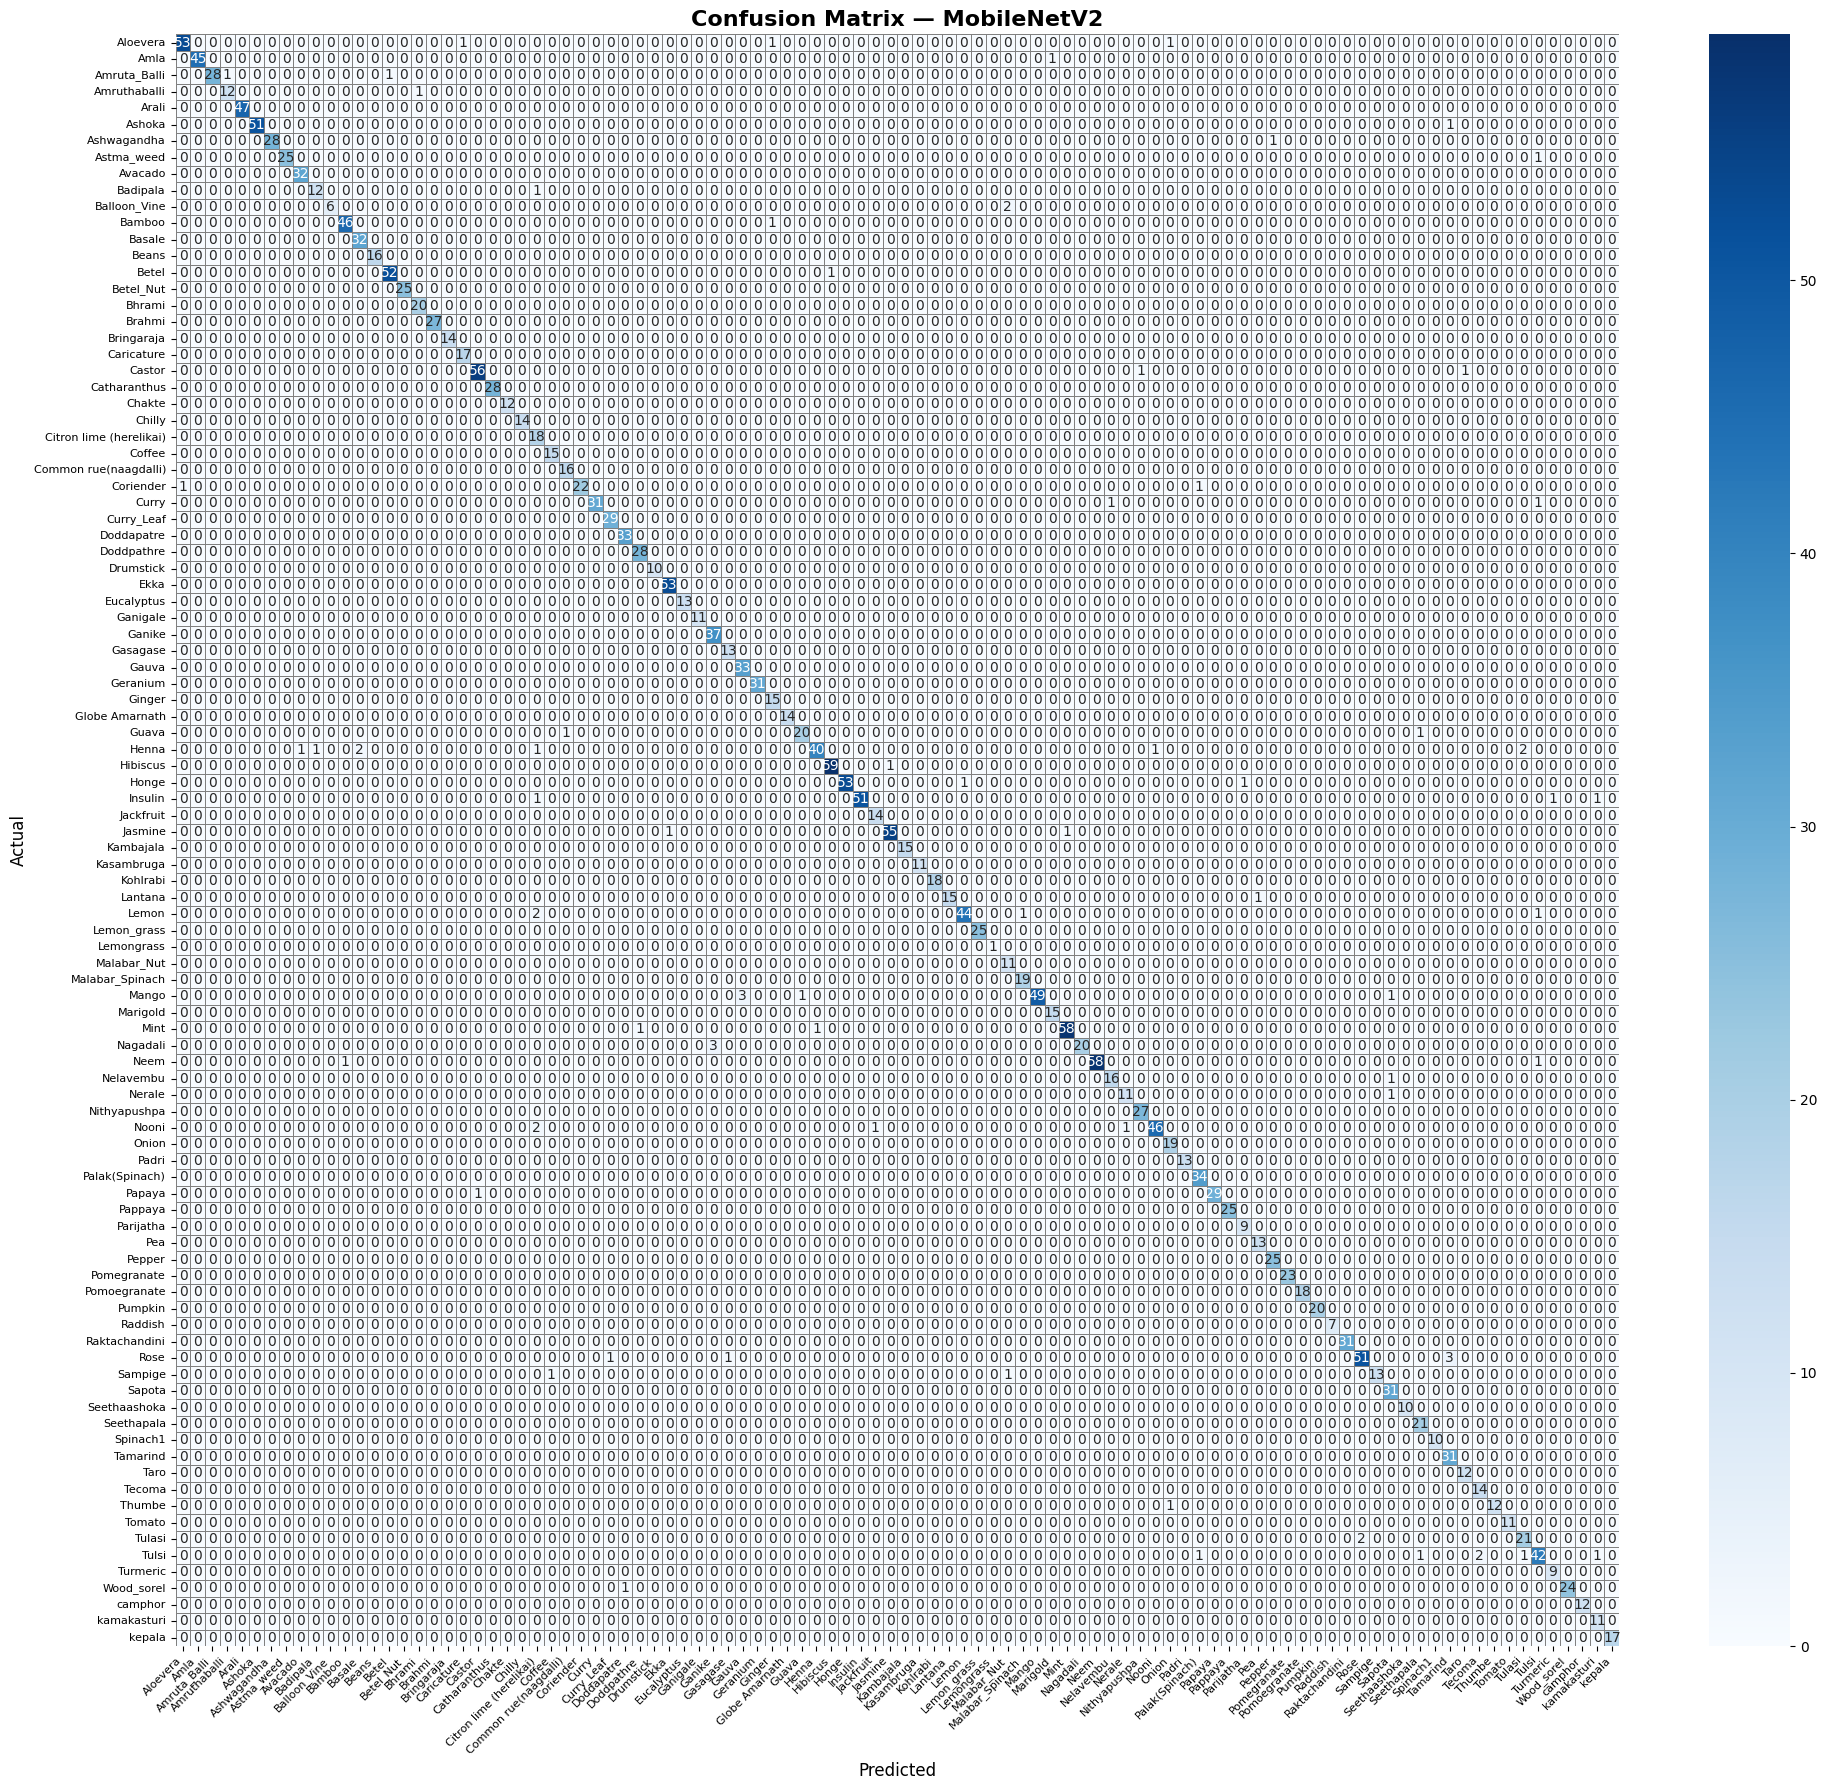

💾 Confusion matrix disimpan: D:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\reports\evaluation\confusion_matrix_mobilenetv2.png


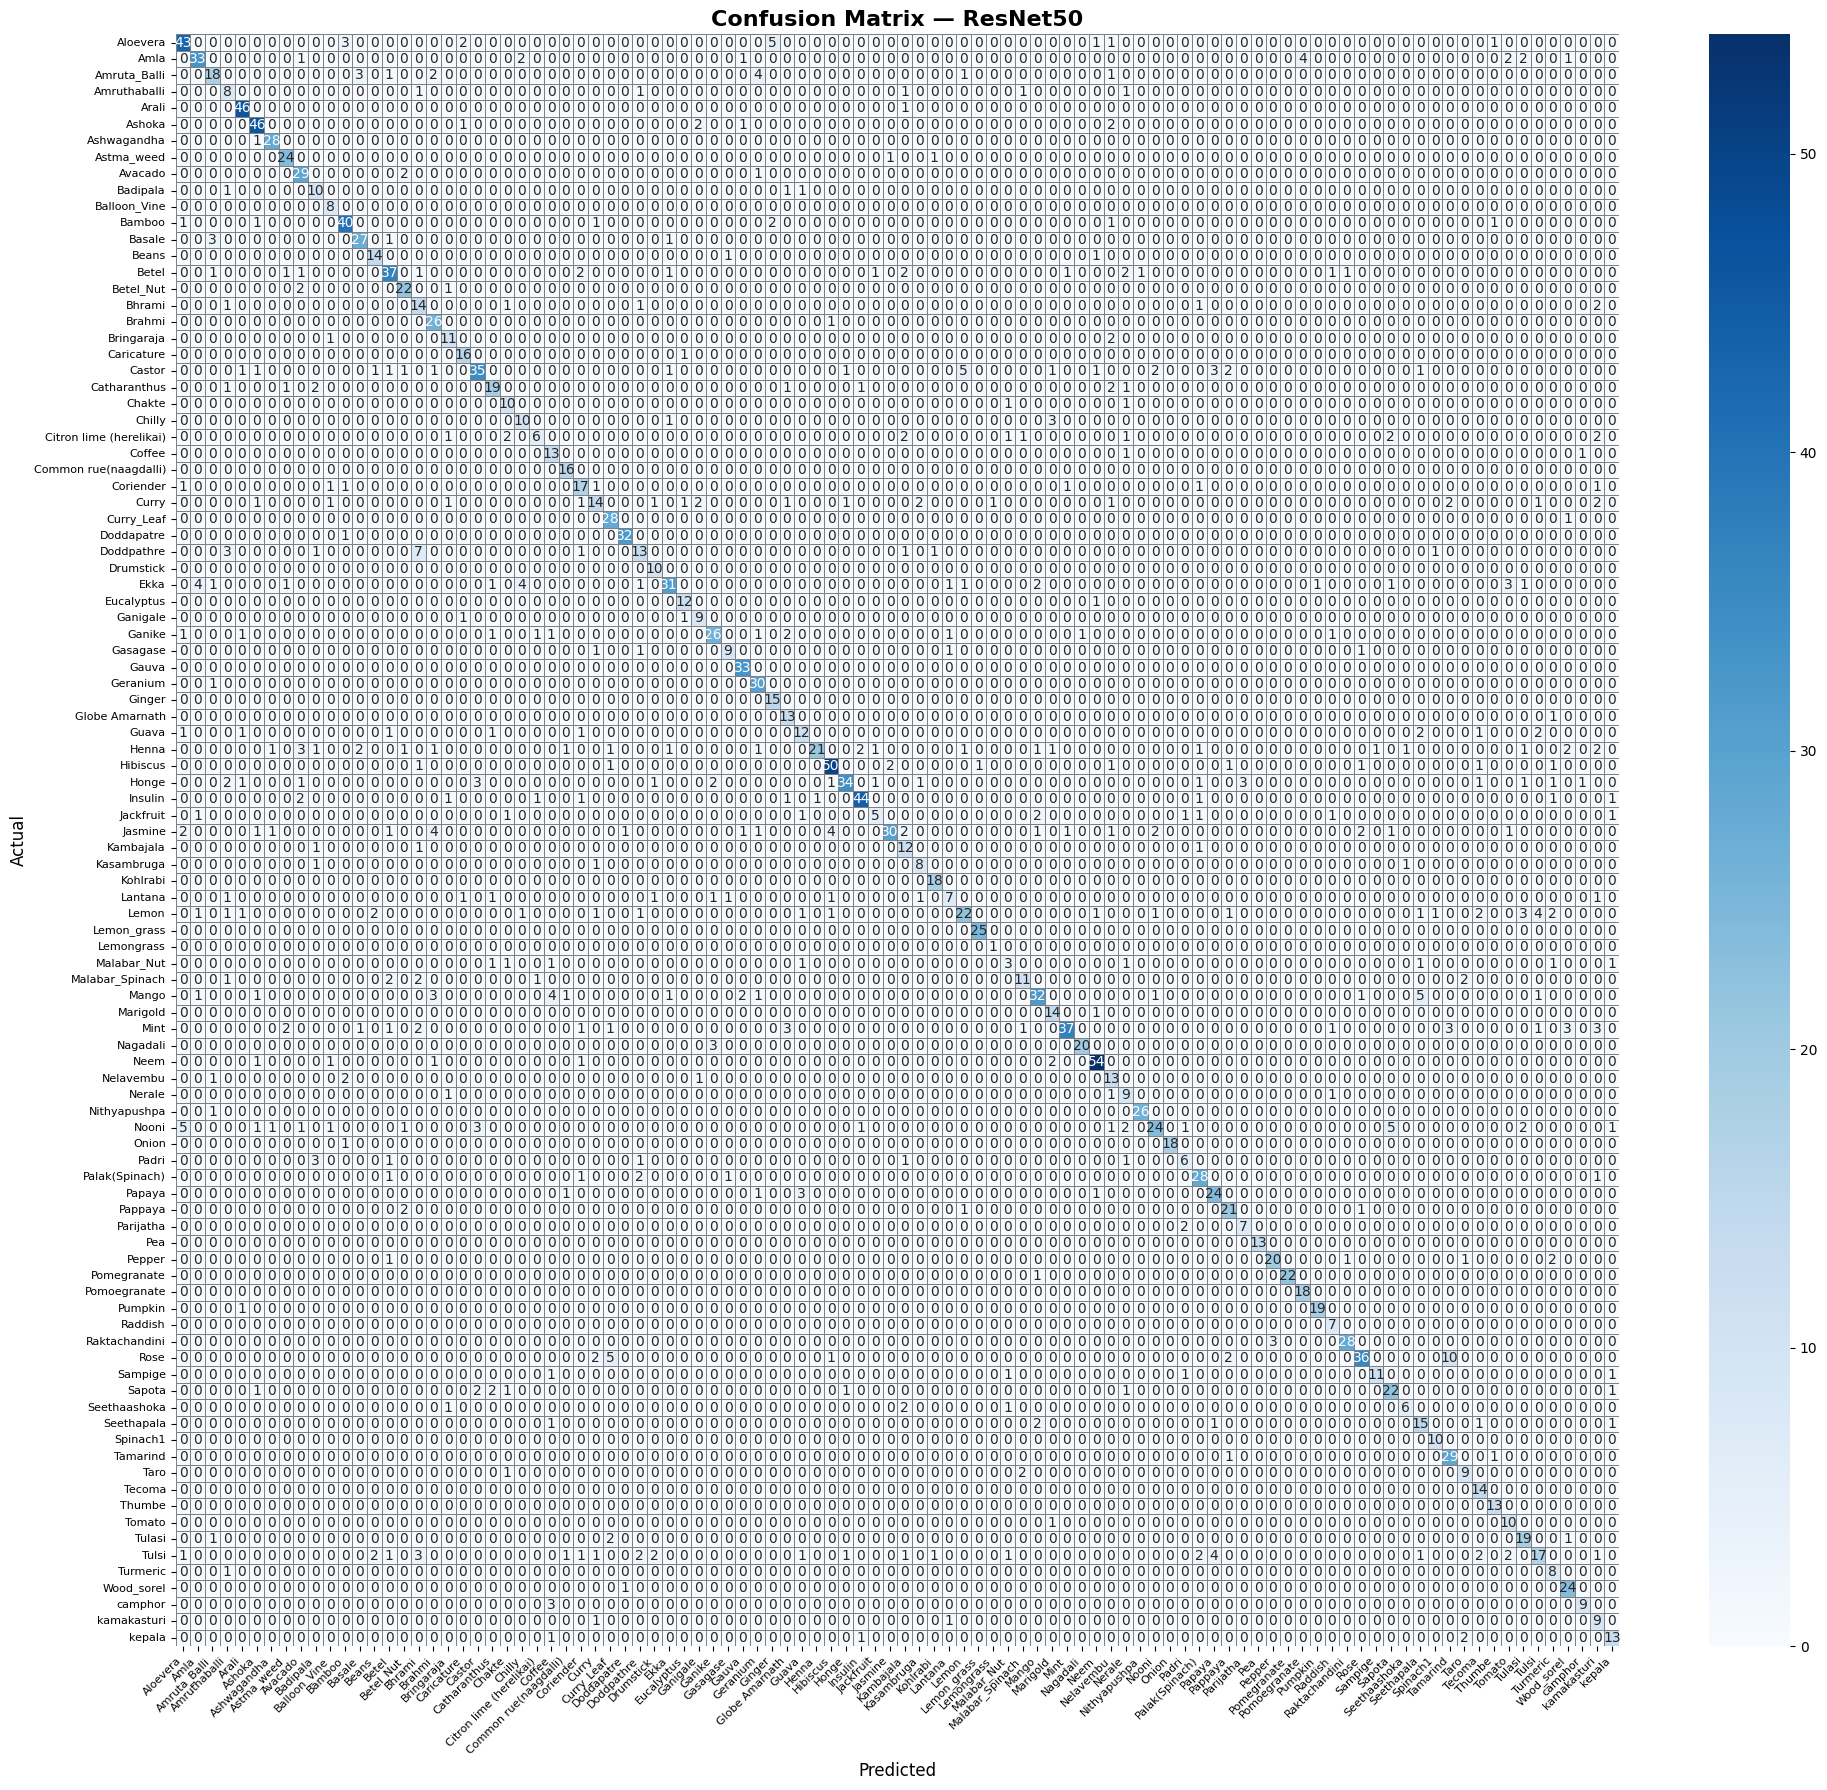

💾 Confusion matrix disimpan: D:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\reports\evaluation\confusion_matrix_resnet50.png


In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names, model_name, save_path):
    """Plot dan simpan confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Confusion matrix disimpan: {save_path}")

plot_confusion_matrix(results_mobilenet['labels'], results_mobilenet['preds'], 
                      class_names, "MobileNetV2",
                      os.path.join(REPORTS_EVAL_DIR, 'confusion_matrix_mobilenetv2.png'))

plot_confusion_matrix(results_resnet['labels'], results_resnet['preds'], 
                      class_names, "ResNet50",
                      os.path.join(REPORTS_EVAL_DIR, 'confusion_matrix_resnet50.png'))



### [CELL 5] — Per-Class F1-Score Comparison


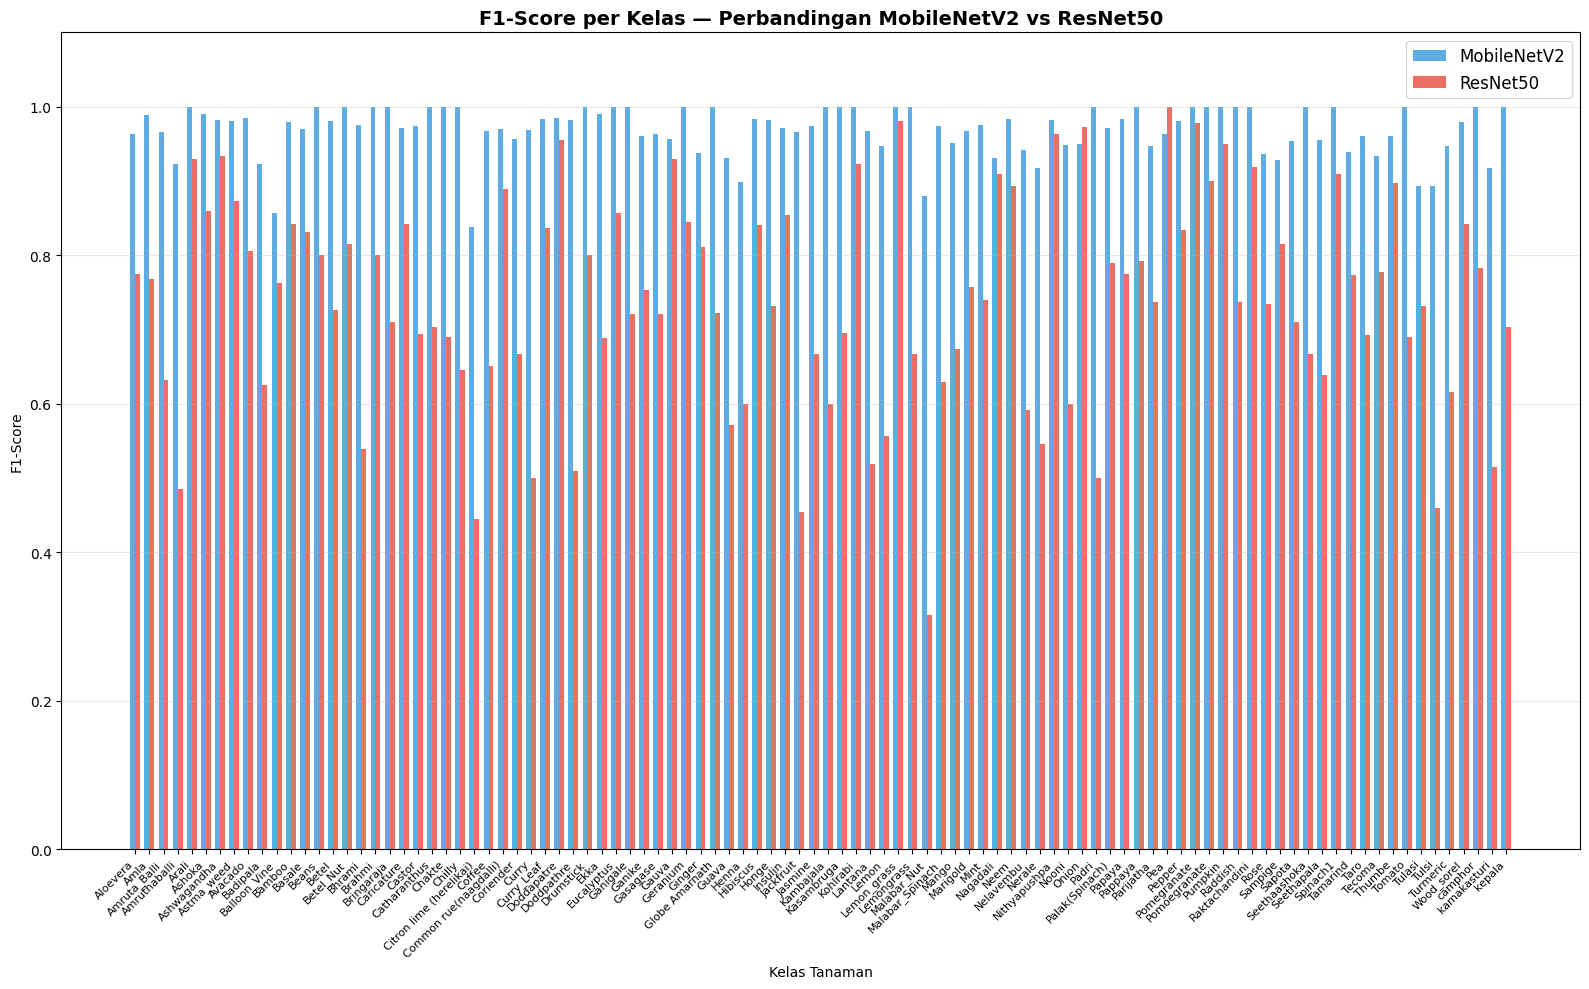

In [8]:
report_mobilenet = classification_report(results_mobilenet['labels'], results_mobilenet['preds'],
                                          target_names=class_names, output_dict=True)
report_resnet = classification_report(results_resnet['labels'], results_resnet['preds'],
                                       target_names=class_names, output_dict=True)

f1_mobilenet = [report_mobilenet[cls]['f1-score'] for cls in class_names]
f1_resnet = [report_resnet[cls]['f1-score'] for cls in class_names]

fig, ax = plt.subplots(figsize=(16, 10))
x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, f1_mobilenet, width, label='MobileNetV2', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_resnet, width, label='ResNet50', color='#e74c3c', alpha=0.8)

ax.set_title('F1-Score per Kelas — Perbandingan MobileNetV2 vs ResNet50', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas Tanaman')
ax.set_ylabel('F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_EVAL_DIR, 'per_class_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()



### [CELL 6] — Training History Comparison


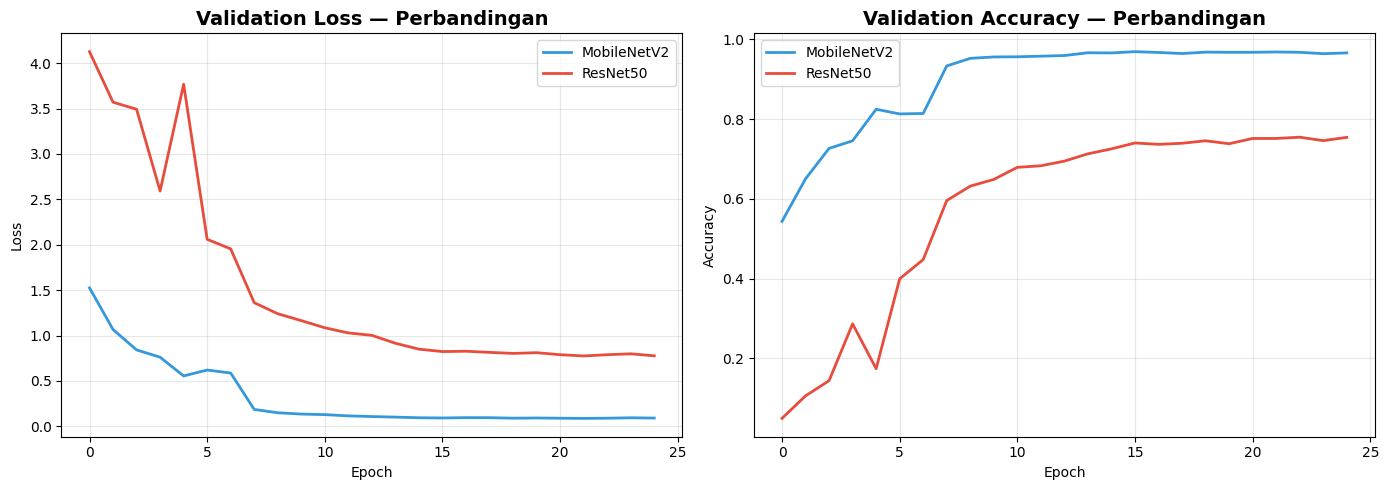

In [9]:
# Load history
with open(os.path.join(MODEL_MOBILENET_DIR, 'mobilenetv2_history.json'), 'r') as f:
    hist_mobilenet = json.load(f)
with open(os.path.join(MODEL_RESNET_DIR, 'resnet50_history.json'), 'r') as f:
    hist_resnet = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(hist_mobilenet['val_loss'], label='MobileNetV2', color='#3498db', linewidth=2)
axes[0].plot(hist_resnet['val_loss'], label='ResNet50', color='#e74c3c', linewidth=2)
axes[0].set_title('Validation Loss — Perbandingan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(hist_mobilenet['val_acc'], label='MobileNetV2', color='#3498db', linewidth=2)
axes[1].plot(hist_resnet['val_acc'], label='ResNet50', color='#e74c3c', linewidth=2)
axes[1].set_title('Validation Accuracy — Perbandingan', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_EVAL_DIR, 'training_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()



### [CELL 7] — Tabel Perbandingan Final


In [10]:
mobilenet_size = os.path.getsize(os.path.join(MODEL_MOBILENET_DIR, "mobilenetv2_best.pth")) / (1024*1024)
resnet_size = os.path.getsize(os.path.join(MODEL_RESNET_DIR, "resnet50_best.pth")) / (1024*1024)

comparison_data = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
               'Avg Inference (ms)', 'Model Size (MB)', 'Total Parameters'],
    'MobileNetV2': [
        f"{results_mobilenet['accuracy']:.4f}",
        f"{results_mobilenet['precision']:.4f}",
        f"{results_mobilenet['recall']:.4f}",
        f"{results_mobilenet['f1_score']:.4f}",
        f"{results_mobilenet['avg_inference_ms']:.2f}",
        f"{mobilenet_size:.1f}",
        f"{sum(p.numel() for p in mobilenet.parameters()):,}"
    ],
    'ResNet50': [
        f"{results_resnet['accuracy']:.4f}",
        f"{results_resnet['precision']:.4f}",
        f"{results_resnet['recall']:.4f}",
        f"{results_resnet['f1_score']:.4f}",
        f"{results_resnet['avg_inference_ms']:.2f}",
        f"{resnet_size:.1f}",
        f"{sum(p.numel() for p in resnet.parameters()):,}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("📊 TABEL PERBANDINGAN FINAL: MobileNetV2 vs ResNet50")
print("="*70)
print(df_comparison.to_string(index=False))




📊 TABEL PERBANDINGAN FINAL: MobileNetV2 vs ResNet50
            Metrik MobileNetV2   ResNet50
          Accuracy      0.9689     0.7544
         Precision      0.9711     0.7735
            Recall      0.9689     0.7544
          F1-Score      0.9689     0.7492
Avg Inference (ms)      626.10    1971.81
   Model Size (MB)         9.2       90.7
  Total Parameters   2,349,410 23,708,834


### [CELL 8] — Simpan Hasil Evaluasi


In [11]:
evaluation_results = {
    'mobilenetv2': {
        'accuracy': results_mobilenet['accuracy'],
        'precision': results_mobilenet['precision'],
        'recall': results_mobilenet['recall'],
        'f1_score': results_mobilenet['f1_score'],
        'avg_inference_ms': results_mobilenet['avg_inference_ms'],
        'model_size_mb': mobilenet_size,
    },
    'resnet50': {
        'accuracy': results_resnet['accuracy'],
        'precision': results_resnet['precision'],
        'recall': results_resnet['recall'],
        'f1_score': results_resnet['f1_score'],
        'avg_inference_ms': results_resnet['avg_inference_ms'],
        'model_size_mb': resnet_size,
    }
}

eval_path = os.path.join(REPORTS_EVAL_DIR, 'evaluation_results.json')
with open(eval_path, 'w') as f:
    json.dump(evaluation_results, f, indent=2)
print(f"\n💾 Hasil evaluasi disimpan: {eval_path}")




💾 Hasil evaluasi disimpan: D:\Local Disk D\Tugas\Semester 6\Aplikasi Pembelajaran Mesin\Project TB\backend\reports\evaluation\evaluation_results.json


### [CELL 9] — Rekomendasi Model Terbaik


In [12]:
print("\n" + "="*70)
print("🏆 REKOMENDASI MODEL UNTUK PRODUCTION")
print("="*70)

if results_mobilenet['f1_score'] >= results_resnet['f1_score'] * 0.97:
    # Jika MobileNetV2 akurasinya mendekati ResNet50 (selisih < 3%)
    print("""
    ✅ REKOMENDASI: MobileNetV2
    
    Alasan:
    - Ukuran model jauh lebih kecil → lebih cepat deploy & load
    - Inference time lebih cepat → UX lebih responsif
    - Akurasi cukup kompetitif dengan ResNet50
    - Ideal untuk serving via API (FastAPI) dan potensi on-device inference
    """)
    recommended = "mobilenetv2"
else:
    print("""
    ✅ REKOMENDASI: ResNet50
    
    Alasan:
    - Akurasi signifikan lebih tinggi dari MobileNetV2
    - Deep feature extraction lebih kuat untuk dataset kompleks
    - Trade-off ukuran model sebanding dengan peningkatan akurasi
    """)
    recommended = "resnet50"

print(f"   → Model '{recommended}' akan digunakan di backend API (FastAPI)")
print(f"   → File: trained_models/{recommended}_best.pth")

# Simpan rekomendasi ke file
comparison_md = f"""# Perbandingan Model: MobileNetV2 vs ResNet50

## Tabel Perbandingan

{df_comparison.to_markdown(index=False)}

## Rekomendasi

**Model terbaik untuk production: {recommended.upper()}**

Model ini akan di-load oleh FastAPI backend untuk endpoint `/predict`.
"""

with open(os.path.join(REPORTS_EVAL_DIR, 'model_comparison.md'), 'w', encoding='utf-8') as f:
    f.write(comparison_md)
print(f"📄 Perbandingan disimpan: reports/model_comparison.md")



🏆 REKOMENDASI MODEL UNTUK PRODUCTION

    ✅ REKOMENDASI: MobileNetV2

    Alasan:
    - Ukuran model jauh lebih kecil → lebih cepat deploy & load
    - Inference time lebih cepat → UX lebih responsif
    - Akurasi cukup kompetitif dengan ResNet50
    - Ideal untuk serving via API (FastAPI) dan potensi on-device inference
    
   → Model 'mobilenetv2' akan digunakan di backend API (FastAPI)
   → File: trained_models/mobilenetv2_best.pth
📄 Perbandingan disimpan: reports/model_comparison.md
